<h1 style="text-align:center;">Song Success Prediction Model</h1>
<h2 style="text-align:center;">Modeling</h2>

<h4 style="text-align:center;">by Cameron Hicks</h3>

V2 of The Song Success Prediction Model project aims to create a Machine Learning Model that can predict if a song will be a hit in the early or pre-release stages of production. The objective of this notebook is to train 3 Machine Learning Models and ultimately determine the best model to select as the final output of this project. In the steps below each model will be trained on the training data sets, then their accuracy will be tested using the test data sets. All three models will be objectively compared to make the final determination.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    auc,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    precision_recall_curve
)

# Import Data

In [2]:
X_train_scaled = pd.read_csv('../../Data/V2_X_train_scaled.csv')
X_test_scaled = pd.read_csv('../../Data/V2_X_test_scaled.csv')
y_train = pd.read_csv('../../Data/V2_y_train.csv')
y_test = pd.read_csv('../../Data/V2_y_test.csv')

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
print(y_train.value_counts())
print(y_test.value_counts())


hit
0    54664
1    13299
Name: count, dtype: int64
hit
0    13666
1     3325
Name: count, dtype: int64


In [5]:
print("Train % hits:", y_train.mean())
print("Test % hits:", y_test.mean())


Train % hits: 0.19568000235422214
Test % hits: 0.19569183685480548


In [6]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))

print("y_train unique:", np.unique(y_train))
print("y_test unique:", np.unique(y_test))


X_train_scaled shape: (67963, 84)
X_test_scaled shape: (16991, 84)
y_train distribution: [54664 13299]
y_test distribution: [13666  3325]
y_train unique: [0 1]
y_test unique: [0 1]


In [7]:
def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    }

# Model 1 Logistic Regression


=== Logistic Regression ===
Accuracy : 0.4924
Precision: 0.1967
Recall   : 0.5170
F1 Score : 0.2850
ROC AUC  : 0.5024

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.49      0.61     13666
           1       0.20      0.52      0.29      3325

    accuracy                           0.49     16991
   macro avg       0.50      0.50      0.45     16991
weighted avg       0.69      0.49      0.54     16991



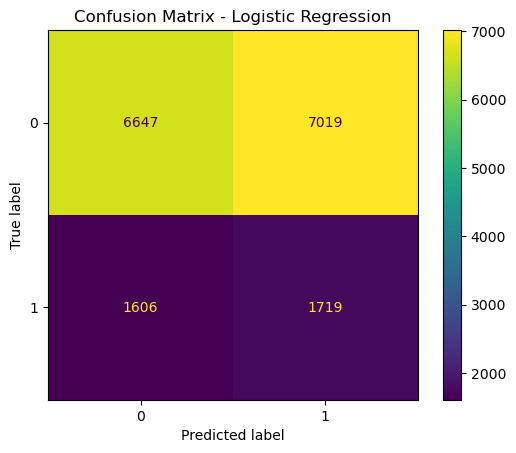

In [8]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"  # important due to imbalance
)

log_reg.fit(X_train_scaled, y_train)

results = []
results.append(evaluate_classifier(log_reg, X_test_scaled, y_test, "Logistic Regression"))

# Model 2 - Random Forest Classifier


=== Random Forest ===
Accuracy : 0.8043
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.4978

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     13666
           1       0.00      0.00      0.00      3325

    accuracy                           0.80     16991
   macro avg       0.40      0.50      0.45     16991
weighted avg       0.65      0.80      0.72     16991



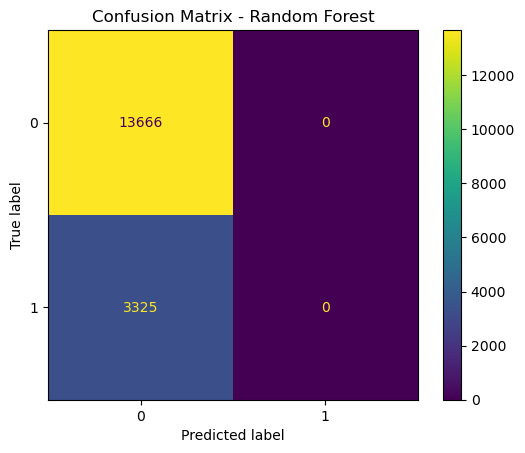

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_scaled, y_train)

results.append(evaluate_classifier(rf, X_test_scaled, y_test, "Random Forest"))

In [10]:
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Min:", y_prob_rf.min())
print("Max:", y_prob_rf.max())
print("Mean:", y_prob_rf.mean())

Min: 0.07666666666666666
Max: 0.4166666666666667
Mean: 0.1972958232789908


In [11]:
y_pred_rf = (y_prob_rf >= 0.15).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.11      0.19     13666
           1       0.20      0.89      0.32      3325

    accuracy                           0.26     16991
   macro avg       0.50      0.50      0.26     16991
weighted avg       0.68      0.26      0.22     16991



# Model 3 - Gradient Boosting Classifier


=== Gradient Boosting ===
Accuracy : 0.8043
Precision: 0.5000
Recall   : 0.0003
F1 Score : 0.0006
ROC AUC  : 0.4984

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     13666
           1       0.50      0.00      0.00      3325

    accuracy                           0.80     16991
   macro avg       0.65      0.50      0.45     16991
weighted avg       0.74      0.80      0.72     16991



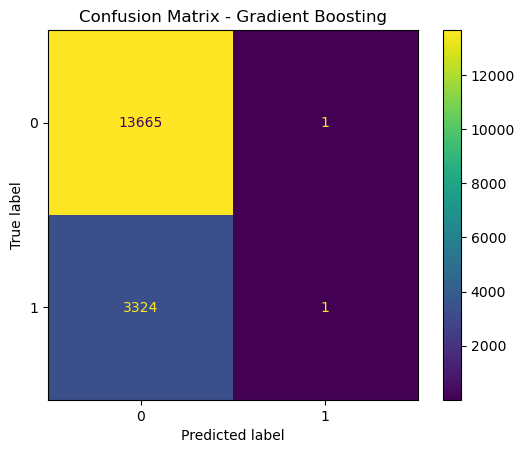

In [12]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

results.append(evaluate_classifier(gb, X_test_scaled, y_test, "Gradient Boosting"))

# Compare Models

In [13]:
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.492378,0.196727,0.516992,0.285004,0.502415
2,Gradient Boosting,0.804308,0.500000,0.000301,0.000601,0.498433
1,Random Forest,0.804308,0.000000,0.000000,0.000000,0.497782


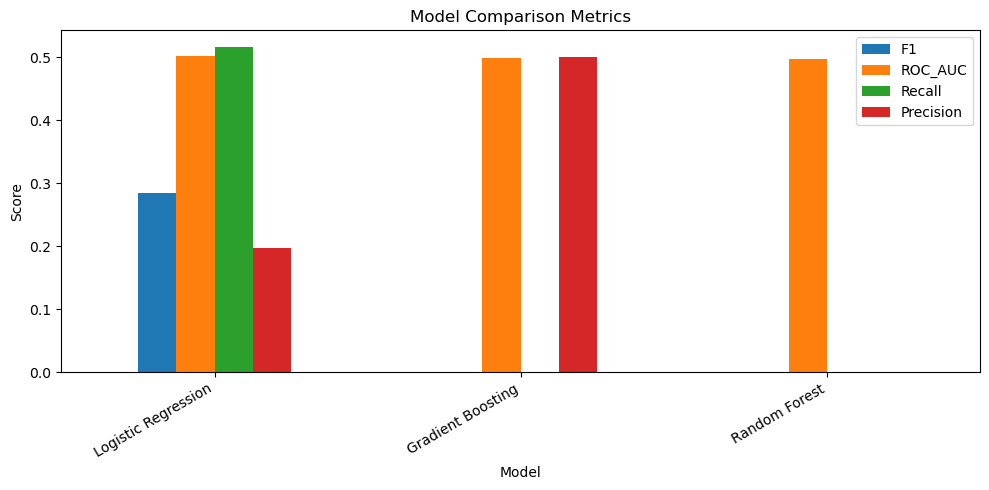

In [14]:
results_df.set_index("Model")[["F1", "ROC_AUC", "Recall", "Precision"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

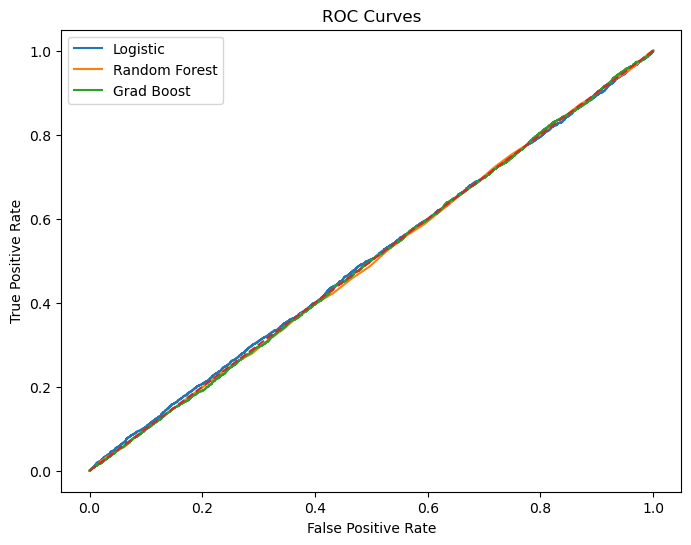

In [15]:
plt.figure(figsize=(8, 6))

for model, name in [(log_reg, "Logistic"), (rf, "Random Forest"), (gb, "Grad Boost")]:
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


# V2 Conclusion

While results may look promising at first glance for this version, the results can be misleading. The Logistic Regression Model shows an accuracy score of 49%, wiht this score we can determine it is ultimely guessing and is correct about 50% of the time. Random Forest and Gradient Boosting both show promice with an accuracy score of approximately 80%, however with their low scores in Precision and Recall, we can see that they are simply noticing that they will be most accurate by consistently guessing the same result everytime. 

With these results we can conclude that the dataset does not contain enough correlating features to determine if a song will be a hit in early or pre-release phases.